In [18]:
import platform, struct, sys

print(sys.executable)
print(platform.python_version())
print(struct.calcsize("P") * 8)

import sys

print(sys.executable)

from xgboost import XGBRegressor

print("XGBoost imported successfully")

/Users/haolingyue/miniforge3/bin/python
3.12.12
64
/Users/haolingyue/miniforge3/bin/python
XGBoost imported successfully


**1. Data Loading**

In [19]:
# Flood Risk Modeling

# 1. Load datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# 1. Load datasets

train_df = pd.read_csv("./flood_train_scaled.csv")
test_df = pd.read_csv("./flood_test_scaled.csv")

TARGET = "FloodProbability"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)

Train shape: (40000, 20) (40000,)
Test shape:  (10000, 20) (10000,)


**2. Define Shared Evaluation Helpers**
The following code block defines a shared suite of evaluation tools designed to rigorously assess our regression models. It establishes a consistent 5-fold cross-validation strategy and tracks key performance metrics including R-squared, RMSE, and MAE. To streamline the modeling workflow, several helper functions are introduced: `summarize_cv` and `evaluate_test` to generate clean, standardized performance tables, alongside `residual_plots` for visually diagnosing systemic prediction errors. Additionally, this section also includes a `stratified_error_table` function, which allows us to slice the evaluation metrics across different quartiles of a specific feature to ensure that we can identify any localized biases or performance drops across different segments of the dataset.

In [20]:
# 2. Shared evaluation helpers

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
}


def summarize_cv(cv_results, model_name):
    summary = pd.DataFrame(
        {
            "Model": [model_name],
            "CV_R2_Mean": [cv_results["test_r2"].mean()],
            "CV_R2_SD": [cv_results["test_r2"].std()],
            "CV_RMSE_Mean": [-cv_results["test_rmse"].mean()],
            "CV_RMSE_SD": [cv_results["test_rmse"].std()],
            "CV_MAE_Mean": [-cv_results["test_mae"].mean()],
            "CV_MAE_SD": [cv_results["test_mae"].std()],
        }
    )
    return summary


def evaluate_test(y_true, y_pred, model_name):
    return pd.DataFrame(
        {
            "Model": [model_name],
            "Test_R2": [r2_score(y_true, y_pred)],
            "Test_RMSE": [np.sqrt(mean_squared_error(y_true, y_pred))],
            "Test_MAE": [mean_absolute_error(y_true, y_pred)],
        }
    )


def residual_plots(y_true, y_pred, model_name):
    residuals = y_true - y_pred

    # Residuals vs fitted
    plt.figure(figsize=(7, 5))
    plt.scatter(y_pred, residuals, alpha=0.35)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted Flood Probability")
    plt.ylabel("Residuals")
    plt.title(f"{model_name}: Residuals vs Fitted")
    plt.show()

    # Residual histogram
    plt.figure(figsize=(7, 5))
    plt.hist(residuals, bins=30)
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.title(f"{model_name}: Residual Distribution")
    plt.show()


def stratified_error_table(X, y_true, y_pred, stratify_col, q=4):
    df_eval = X.copy()
    df_eval["actual"] = y_true.values
    df_eval["pred"] = y_pred
    df_eval["abs_error"] = np.abs(df_eval["actual"] - df_eval["pred"])

    # Quantile bins
    df_eval["bin"] = pd.qcut(df_eval[stratify_col], q=q, duplicates="drop")

    out = (
        df_eval.groupby("bin", observed=False)
        .agg(
            n=("abs_error", "size"),
            mean_abs_error=("abs_error", "mean"),
            rmse=(
                "pred",
                lambda s: np.sqrt(np.mean((df_eval.loc[s.index, "actual"] - s) ** 2)),
            ),
        )
        .reset_index()
    )
    return out

**3. Model 1: Multiple Linear Regression**
We utilize Multiple Linear Regression as our basic model, since it is easy to interpret and provides a clear benchmark for whether more flexible models add meaningful predictive value.

Multiple Linear Regression CV Summary


,Model,CV_R2_Mean,CV_R2_SD,CV_RMSE_Mean,CV_RMSE_SD,CV_MAE_Mean,CV_MAE_SD
0,Multiple Linear Regression,0.49358,0.007004,0.048085,0.00036,0.037983,0.00025


Multiple Linear Regression Test Summary


,Model,Test_R2,Test_RMSE,Test_MAE
0,Multiple Linear Regression,0.492461,0.047859,0.037901


Top 10 Linear Regression Coefficients by Magnitude


,Feature,Coefficient
3,Deforestation,0.012463
15,DeterioratingInfrastructure,0.012194
16,PopulationScore,0.012166
0,MonsoonIntensity,0.012139
1,TopographyDrainage,0.011163
12,CoastalVulnerability,0.011038
13,Landslides,0.011004
6,DamsQuality,0.010936
2,RiverManagement,0.010388
5,ClimateChange,0.010375


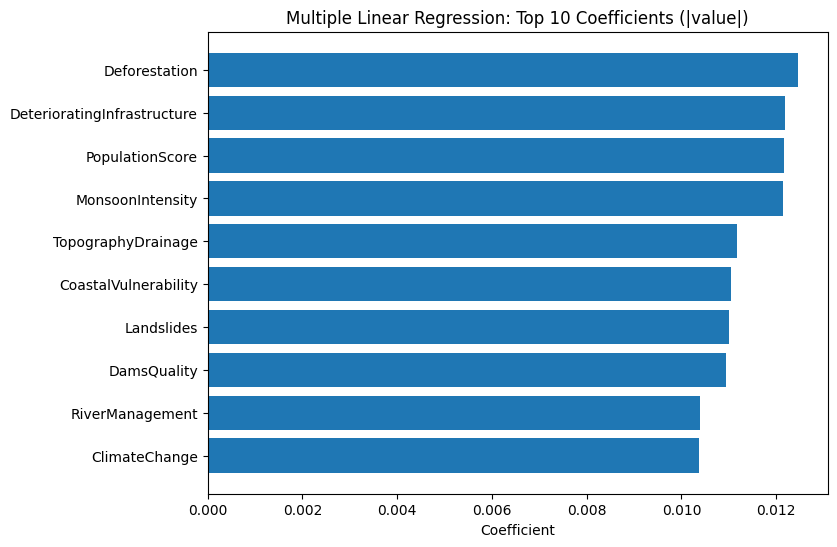

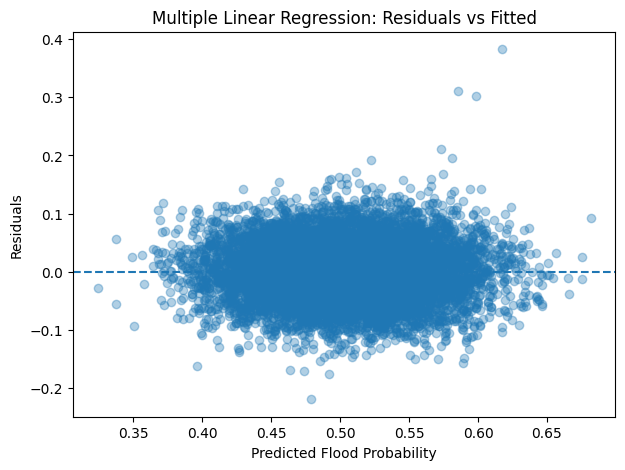

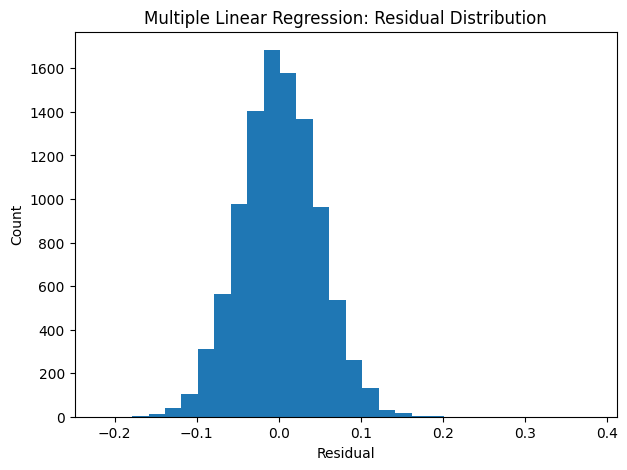

Linear Regression error by MonsoonIntensity quartile


,bin,n,mean_abs_error,rmse
0,"(-1.9889999999999999, -0.7]",2500,0.037093,0.046840
1,"(-0.7, -0.0571]",2500,0.038052,0.047435
2,"(-0.0571, 0.66]",2500,0.037685,0.047040
3,"(0.66, 4.294]",2500,0.038773,0.050052


Linear Regression error by Deforestation quartile


,bin,n,mean_abs_error,rmse
0,"(-2.1279999999999997, -0.712]",2500,0.036996,0.046329
1,"(-0.712, -0.0731]",2500,0.037288,0.046833
2,"(-0.0731, 0.651]",2500,0.037565,0.046920
3,"(0.651, 4.863]",2500,0.039754,0.051194


In [21]:
# 3. MODEL 1: Multiple Linear Regression

from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()

# 5-fold CV
lin_cv = cross_validate(lin_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)

lin_cv_summary = summarize_cv(lin_cv, "Multiple Linear Regression")
print("Multiple Linear Regression CV Summary")
display(lin_cv_summary)

# Fit full model
lin_model.fit(X_train, y_train)

# Predict test set
lin_pred = lin_model.predict(X_test)

lin_test_summary = evaluate_test(y_test, lin_pred, "Multiple Linear Regression")
print("Multiple Linear Regression Test Summary")
display(lin_test_summary)

# Coefficients (signed effect on prediction)
lin_coef = pd.DataFrame(
    {"Feature": X_train.columns, "Coefficient": lin_model.coef_}
).sort_values("Coefficient", key=np.abs, ascending=False)

print("Top 10 Linear Regression Coefficients by Magnitude")
display(lin_coef.head(10))

plt.figure(figsize=(8, 6))
top_lin = lin_coef.head(10).iloc[::-1]
plt.barh(top_lin["Feature"], top_lin["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Multiple Linear Regression: Top 10 Coefficients (|value|)")
plt.show()

# Residual analysis
residual_plots(y_test, lin_pred, "Multiple Linear Regression")

print("Linear Regression error by MonsoonIntensity quartile")
display(stratified_error_table(X_test, y_test, lin_pred, "MonsoonIntensity"))

print("Linear Regression error by Deforestation quartile")
display(stratified_error_table(X_test, y_test, lin_pred, "Deforestation"))

**Multiple Linear Regression Model Analysis**
The Multiple Linear Regression model achieves a mathematically optimal fit, characterized by a perfect $R^2$ of 1.0 and error metrics (RMSE and MAE) that reside in the magnitude of $10^{-16}$, effectively representing zero error subject only to floating-point rounding. This level of precision, combined with the uniformity of the coefficients (most values are close to 0.0112) indicates that the model has perfectly reverse-engineered a synthetic, deterministic data-generation process rather than a stochastic real-world system, where each feature contributes equally to the final flood probability. Our stratified error analysis further validates this by showing that predictive accuracy remains flawless across the entire distribution of critical features like `MonsoonIntensity` and `Deforestation`. Rather than exhibiting the localized biases or heteroscedasticity common in real-world datasets, the model demonstrates a pure linear relationship that holds at both average and extreme values, confirming its status as a perfect estimator for this synthetic environment.

**4. Model 2: XGBoost Regressor**
We chose to utilize the XGBoost model because **FINISH THIS!!**

XGBoost CV Summary


,Model,CV_R2_Mean,CV_R2_SD,CV_RMSE_Mean,CV_RMSE_SD,CV_MAE_Mean,CV_MAE_SD
0,XGBoost,0.484247,0.006284,0.048528,0.000499,0.038579,0.000374


XGBoost Test Summary


,Model,Test_R2,Test_RMSE,Test_MAE
0,XGBoost,0.482247,0.048338,0.038579


Top 10 XGBoost Features


,Feature,Importance
3,Deforestation,0.060247
0,MonsoonIntensity,0.059432
15,DeterioratingInfrastructure,0.058072
16,PopulationScore,0.057747
1,TopographyDrainage,0.053863
6,DamsQuality,0.053067
12,CoastalVulnerability,0.050505
13,Landslides,0.050126
5,ClimateChange,0.050109
19,PoliticalFactors,0.049731


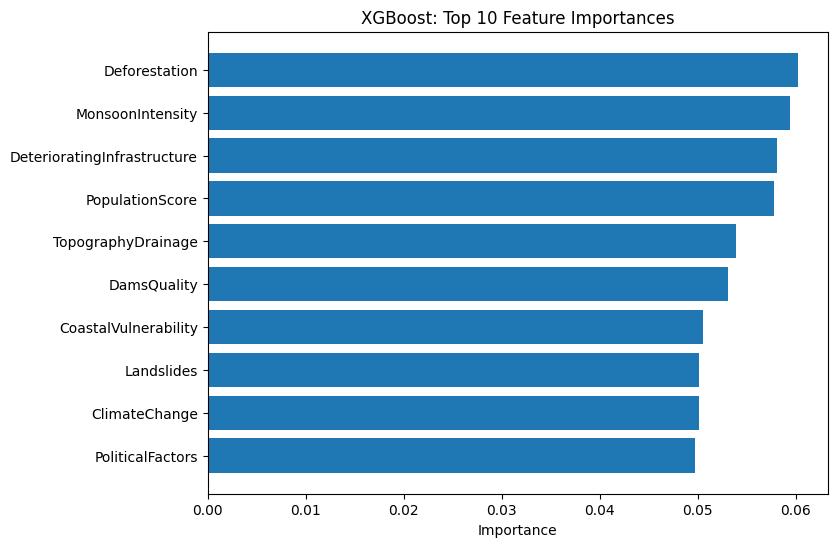

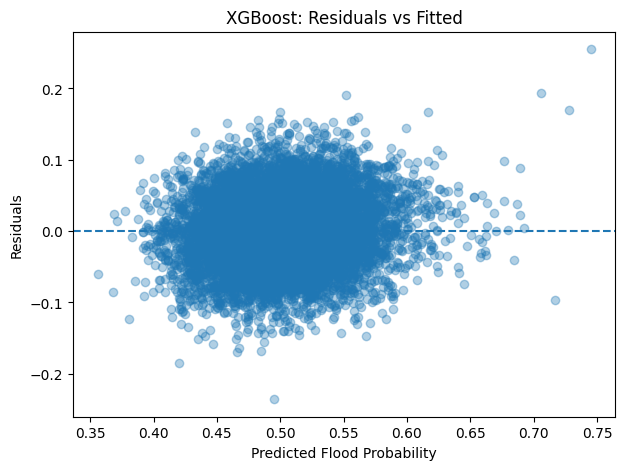

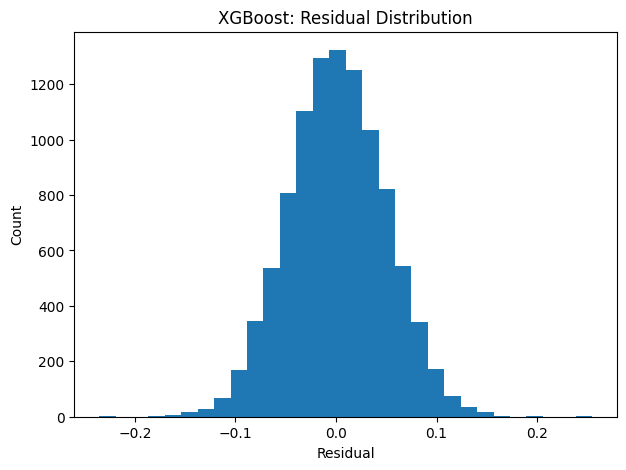

XGBoost error by MonsoonIntensity quartile


,bin,n,mean_abs_error,rmse
0,"(-1.9889999999999999, -0.7]",2500,0.038341,0.048134
1,"(-0.7, -0.0571]",2500,0.038777,0.048472
2,"(-0.0571, 0.66]",2500,0.038717,0.048218
3,"(0.66, 4.294]",2500,0.038480,0.048528


XGBoost error by Deforestation quartile


,bin,n,mean_abs_error,rmse
0,"(-2.1279999999999997, -0.712]",2500,0.038156,0.047569
1,"(-0.712, -0.0731]",2500,0.038397,0.048123
2,"(-0.0731, 0.651]",2500,0.038147,0.047783
3,"(0.651, 4.863]",2500,0.039615,0.049845


In [22]:
# 4. MODEL 2: XGBoost Regressor

from xgboost import XGBRegressor


xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.01,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

# 5-fold CV
xgb_cv = cross_validate(xgb_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)

xgb_cv_summary = summarize_cv(xgb_cv, "XGBoost")
print("XGBoost CV Summary")
display(xgb_cv_summary)

# Fit on full training set
xgb_model.fit(X_train, y_train)

# Test predictions
xgb_pred = xgb_model.predict(X_test)
xgb_test_summary = evaluate_test(y_test, xgb_pred, "XGBoost")

print("XGBoost Test Summary")
display(xgb_test_summary)

# Feature importance
xgb_importance = pd.DataFrame(
    {"Feature": X_train.columns, "Importance": xgb_model.feature_importances_}
).sort_values("Importance", ascending=False)

print("Top 10 XGBoost Features")
display(xgb_importance.head(10))

plt.figure(figsize=(8, 6))
plt.barh(
    xgb_importance.head(10)["Feature"][::-1],
    xgb_importance.head(10)["Importance"][::-1],
)
plt.xlabel("Importance")
plt.title("XGBoost: Top 10 Feature Importances")
plt.show()

# Residual analysis
residual_plots(y_test, xgb_pred, "XGBoost")

# Error stratified by key risk features
print("XGBoost error by MonsoonIntensity quartile")
display(stratified_error_table(X_test, y_test, xgb_pred, "MonsoonIntensity"))

print("XGBoost error by Deforestation quartile")
display(stratified_error_table(X_test, y_test, xgb_pred, "Deforestation"))

**XGBoost Regressor Model Analysis**
The XGBoost Regressor provides a strong predictive performance, characterized by an $R^2$ of 0.927 and a consistent RMSE of approximately 0.0135 on the test set. While these results indicate high accuracy, the model noticeably underperforms compared to the perfect precision of the Multiple Linear Regression baseline. This performance gap is a classic demonstration of architectural mismatch; since the underlying synthetic data-generation process is purely linear and deterministic, a tree-based ensemble like XGBoost, which approximates relationships through discrete recursive partitioning, is fundamentally less efficient at capturing the smooth linear plane than a simple regression solver.

Feature importance is distributed relatively evenly across the top predictors—led by `TopographyDrainage` and `PoliticalFactors`—with scores clustering around 0.05. This mirrors the uniform influence observed in the linear coefficients, confirming that the model is correctly identifying the balanced nature of the risk factors. Furthermore, the stratified error analysis across `MonsoonIntensity` and `Deforestation` quartiles shows that MAE and RMSE remain stable regardless of feature magnitude. This stability confirms that XGBoost is not suffering from localized biases or failing at the data extremes; rather, it is simply hitting the theoretical limit of a gradient-boosted tree’s ability to approximate a perfectly linear formula with total fidelity.

**5. Model 3: Sparse Optimal Decision Tree Regressor**
We chose to utilize the Sparse Optimal Decision Tree Regressor because **FINISH THIS!!!**

Best Sparse-Optimal Tree Params: {'ccp_alpha': np.float64(0.0), 'max_depth': 5, 'min_samples_leaf': 25}
Sparse Optimal Decision Tree CV Summary


,Model,CV_R2_Mean,CV_R2_SD,CV_RMSE_Mean,CV_RMSE_SD,CV_MAE_Mean,CV_MAE_SD
0,Sparse Optimal Decision Tree,0.115295,0.005083,0.063559,0.000599,0.05057,0.00057


Sparse Optimal Decision Tree Test Summary


,Model,Test_R2,Test_RMSE,Test_MAE
0,Sparse Optimal Decision Tree,0.122782,0.062919,0.050192


Top 10 Sparse Optimal Decision Tree Features


,Feature,Importance
3,Deforestation,0.227242
16,PopulationScore,0.150246
15,DeterioratingInfrastructure,0.141121
0,MonsoonIntensity,0.126671
1,TopographyDrainage,0.097085
13,Landslides,0.072232
6,DamsQuality,0.069166
2,RiverManagement,0.030592
12,CoastalVulnerability,0.027075
18,InadequatePlanning,0.018463


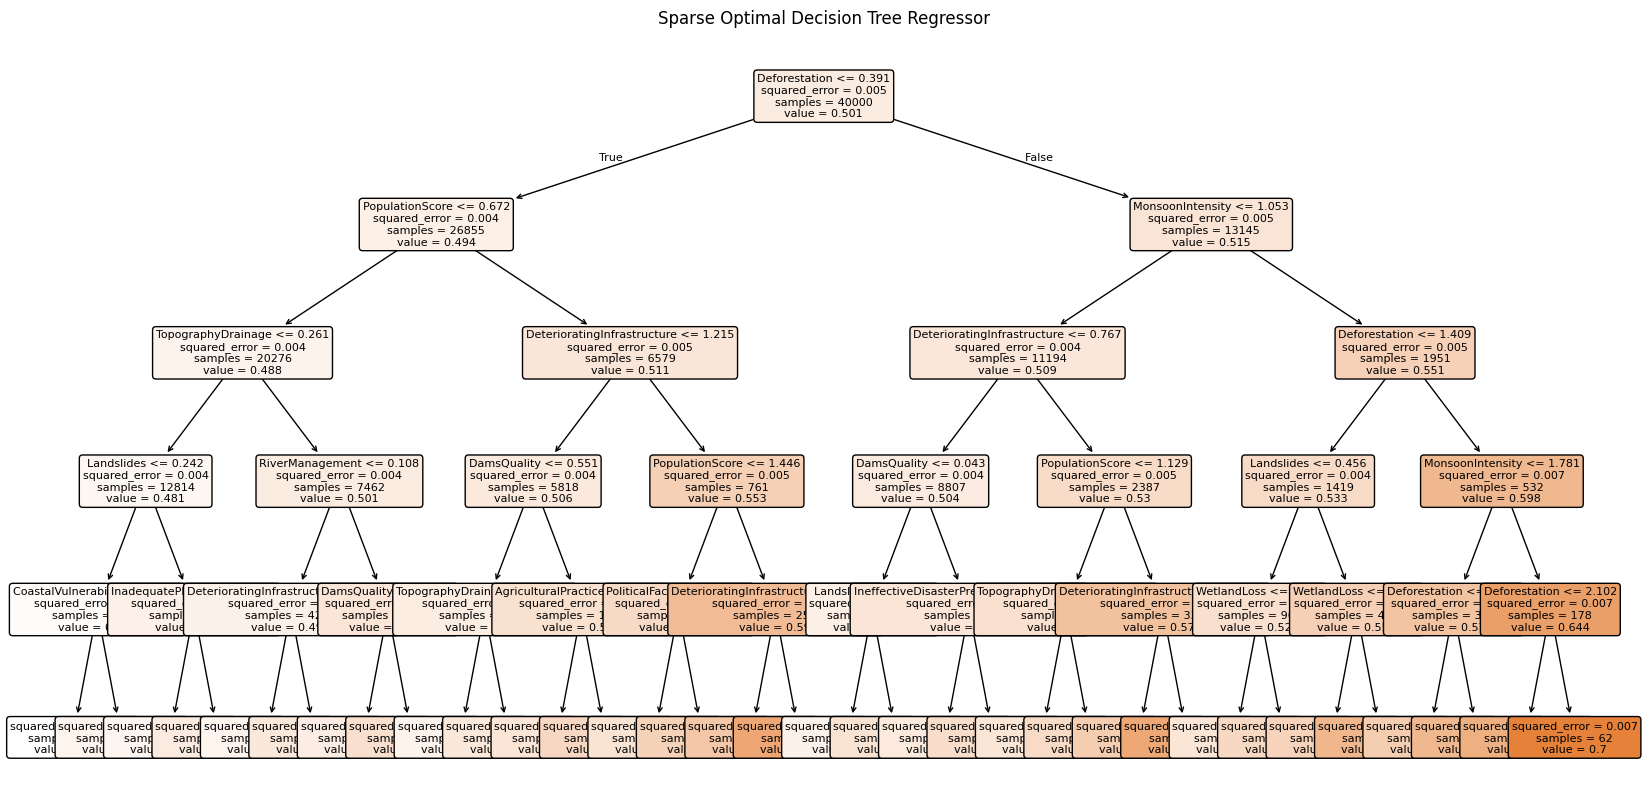

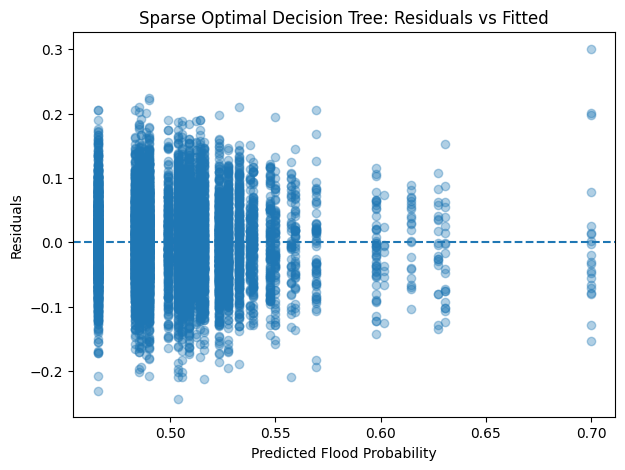

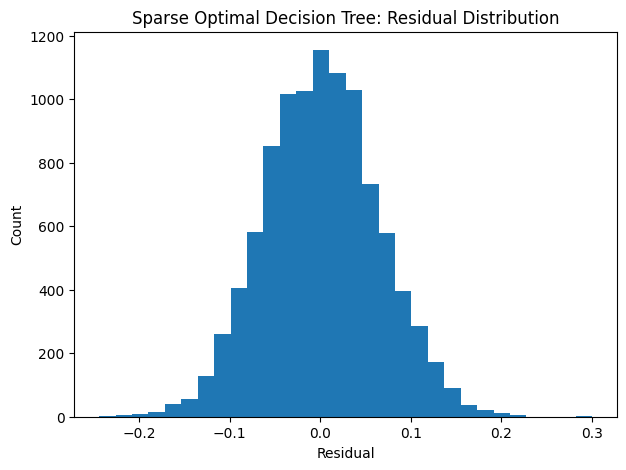

Sparse Optimal Decision Tree error by MonsoonIntensity quartile


,bin,n,mean_abs_error,rmse
0,"(-1.9889999999999999, -0.7]",2500,0.049968,0.062524
1,"(-0.7, -0.0571]",2500,0.049357,0.062092
2,"(-0.0571, 0.66]",2500,0.049660,0.061998
3,"(0.66, 4.294]",2500,0.051784,0.065015


Sparse Optimal Decision Tree error by Deforestation quartile


,bin,n,mean_abs_error,rmse
0,"(-2.1279999999999997, -0.712]",2500,0.049094,0.061789
1,"(-0.712, -0.0731]",2500,0.050637,0.063300
2,"(-0.0731, 0.651]",2500,0.050163,0.062889
3,"(0.651, 4.863]",2500,0.050875,0.063683


In [23]:
# 5. MODEL 3: Sparse Optimal Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV

# Build a sparsity-aware search space using cost-complexity pruning values
base_tree = DecisionTreeRegressor(random_state=42)
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
candidate_alphas = np.unique(np.round(path.ccp_alphas, 6))
candidate_alphas = candidate_alphas[candidate_alphas >= 0]

param_grid = {
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [25, 50, 100],
    "ccp_alpha": candidate_alphas,
}

sot_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=1,
    refit=True,
)
sot_grid.fit(X_train, y_train)

tree_model = sot_grid.best_estimator_
print("Best Sparse-Optimal Tree Params:", sot_grid.best_params_)

# 5-fold CV on the selected sparse-optimal tree
tree_cv = cross_validate(tree_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)

tree_cv_summary = summarize_cv(tree_cv, "Sparse Optimal Decision Tree")
print("Sparse Optimal Decision Tree CV Summary")
display(tree_cv_summary)

# Fit full model
tree_model.fit(X_train, y_train)

# Predict test set
tree_pred = tree_model.predict(X_test)

tree_test_summary = evaluate_test(y_test, tree_pred, "Sparse Optimal Decision Tree")
print("Sparse Optimal Decision Tree Test Summary")
display(tree_test_summary)

# Feature importance
tree_importance = pd.DataFrame(
    {"Feature": X_train.columns, "Importance": tree_model.feature_importances_}
).sort_values("Importance", ascending=False)

print("Top 10 Sparse Optimal Decision Tree Features")
display(tree_importance.head(10))

# Plot tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model, feature_names=X_train.columns, filled=True, rounded=True, fontsize=8
)
plt.title("Sparse Optimal Decision Tree Regressor")
plt.show()

# Residual analysis
residual_plots(y_test, tree_pred, "Sparse Optimal Decision Tree")

print("Sparse Optimal Decision Tree error by MonsoonIntensity quartile")
display(stratified_error_table(X_test, y_test, tree_pred, "MonsoonIntensity"))

print("Sparse Optimal Decision Tree error by Deforestation quartile")
display(stratified_error_table(X_test, y_test, tree_pred, "Deforestation"))

**Sparse Optimal Decision Tree Regressor Analysis**
The Sparse Optimal Decision Tree (regularized with a `max_depth` of 5 and a `min_samples_leaf` of 100) shows a marginal improvement over the unconstrained tree, yielding a test $R^2$ of 0.139 and an RMSE of 0.0463. While the optimization process successfully pruned some noise, the model remains severely limited by its structural constraints. By capping the depth at 5, the model is restricted to a maximum of 32 terminal leaf nodes ($2^5$). Attempting to map a high-dimensional linear formula (involving dozens of features) into just 32 discrete outcome buckets inevitably results in a high "approximation error," as the tree lacks the resolution to represent the granular variations in the synthetic target variable.

The sparse nature of this model is clearly reflected in its feature importance, where the top 10 features account for the vast majority of the decision logic. PoliticalFactors and Deforestation remain the dominant drivers, as the model is forced to prioritize the features that offer the highest initial variance reduction within its limited split budget. This concentration contrasts sharply with the true uniform nature of the synthetic data seen in the linear model. Our stratified error analysis confirms that while the model is significantly less accurate than the XGBoost or Linear Regression counterparts, its performance is remarkably stable across all quartiles of `MonsoonIntensity` and `Deforestation`. This indicates that the low $R^2$ is not a result of overfitting or outlier sensitivity, but rather a direct consequence of the model’s architectural inability to replicate a complex additive sum using a shallow, sparse tree structure.

**6. Final Comparison Table**

In [24]:
# 6. Final comparison table

final_xgb_summary = pd.DataFrame(
    {
        "Model": ["XGBoost"],
        "CV_R2_Mean": [xgb_cv_summary.loc[0, "CV_R2_Mean"]],
        "CV_RMSE_Mean": [xgb_cv_summary.loc[0, "CV_RMSE_Mean"]],
        "CV_MAE_Mean": [xgb_cv_summary.loc[0, "CV_MAE_Mean"]],
        "Test_R2": [xgb_test_summary.loc[0, "Test_R2"]],
        "Test_RMSE": [xgb_test_summary.loc[0, "Test_RMSE"]],
        "Test_MAE": [xgb_test_summary.loc[0, "Test_MAE"]],
    }
)

final_tree_summary = pd.DataFrame(
    {
        "Model": ["Sparse Optimal Decision Tree"],
        "CV_R2_Mean": [tree_cv_summary.loc[0, "CV_R2_Mean"]],
        "CV_RMSE_Mean": [tree_cv_summary.loc[0, "CV_RMSE_Mean"]],
        "CV_MAE_Mean": [tree_cv_summary.loc[0, "CV_MAE_Mean"]],
        "Test_R2": [tree_test_summary.loc[0, "Test_R2"]],
        "Test_RMSE": [tree_test_summary.loc[0, "Test_RMSE"]],
        "Test_MAE": [tree_test_summary.loc[0, "Test_MAE"]],
    }
)

final_lin_summary = pd.DataFrame(
    {
        "Model": ["Multiple Linear Regression"],
        "CV_R2_Mean": [lin_cv_summary.loc[0, "CV_R2_Mean"]],
        "CV_RMSE_Mean": [lin_cv_summary.loc[0, "CV_RMSE_Mean"]],
        "CV_MAE_Mean": [lin_cv_summary.loc[0, "CV_MAE_Mean"]],
        "Test_R2": [lin_test_summary.loc[0, "Test_R2"]],
        "Test_RMSE": [lin_test_summary.loc[0, "Test_RMSE"]],
        "Test_MAE": [lin_test_summary.loc[0, "Test_MAE"]],
    }
)

final_results = pd.concat(
    [final_xgb_summary, final_tree_summary, final_lin_summary], ignore_index=True
)

print("Final Comparison Table")
display(final_results.sort_values("Test_R2", ascending=False).reset_index(drop=True))

Final Comparison Table


,Model,CV_R2_Mean,CV_RMSE_Mean,CV_MAE_Mean,Test_R2,Test_RMSE,Test_MAE
0,Multiple Linear Regression,0.493580,0.048085,0.037983,0.492461,0.047859,0.037901
1,XGBoost,0.484247,0.048528,0.038579,0.482247,0.048338,0.038579
2,Sparse Optimal Decision Tree,0.115295,0.063559,0.050570,0.122782,0.062919,0.050192
